In [6]:
import pandas as pd

df = pd.read_csv("Shoping_table_std.csv")   # ya jo bhi tumne file ka naam diya hai

df.head()

,CustomerID,Age,Gender,ItemPurchased,Category,PurchaseAmountUSD,Location,Size,Color,Season,ReviewRating,SubscriptionStatus,ShippingType,DiscountApplied,PromoCodeUsed,PreviousPurchases,PaymentMethod,FrequencyOfPurchases,Age_Group
0,1,56,Male,Bag,Accessories,374.86,New York,L,Red,Fall,3,No,Standard,Yes,No,7,PayPal,Fortnightly,50s
1,2,46,Male,Shoes,Home Decor,33.28,Los Angeles,S,Black,Spring,2,No,Express,Yes,No,3,UPI,Weekly,40s
2,3,32,Female,Laptop,Home Decor,117.45,Houston,S,Black,Fall,4,No,Standard,Yes,Yes,13,UPI,Monthly,30s
3,4,60,Male,Bag,Home Decor,356.05,Chicago,M,Green,Summer,2,Yes,Express,No,No,14,PayPal,Weekly,60+
4,5,25,Female,Laptop,Accessories,393.50,Houston,M,Black,Winter,2,Yes,Express,No,No,5,Cash,Fortnightly,20s


In [7]:
df.info() # info of data 
df.describe() # Descripe Data 
df.isnull().sum() # null data show 
df.columns 

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CustomerID            3900 non-null   int64  
 1   Age                   3900 non-null   int64  
 2   Gender                3900 non-null   str    
 3   ItemPurchased         3900 non-null   str    
 4   Category              3900 non-null   str    
 5   PurchaseAmountUSD     3900 non-null   float64
 6   Location              3900 non-null   str    
 7   Size                  3900 non-null   str    
 8   Color                 3900 non-null   str    
 9   Season                3900 non-null   str    
 10  ReviewRating          3900 non-null   int64  
 11  SubscriptionStatus    3900 non-null   str    
 12  ShippingType          3900 non-null   str    
 13  DiscountApplied       3900 non-null   str    
 14  PromoCodeUsed         3900 non-null   str    
 15  PreviousPurchases     3900 non-n

Index(['CustomerID', 'Age', 'Gender', 'ItemPurchased', 'Category',
       'PurchaseAmountUSD', 'Location', 'Size', 'Color', 'Season',
       'ReviewRating', 'SubscriptionStatus', 'ShippingType', 'DiscountApplied',
       'PromoCodeUsed', 'PreviousPurchases', 'PaymentMethod',
       'FrequencyOfPurchases', 'Age_Group'],
      dtype='str')

In [8]:
category_sales = df.groupby("Category")["PurchaseAmountUSD"].sum().sort_values(ascending=False)
print(category_sales)

Category
Clothing       208775.03
Accessories    208063.00
Home Decor     196999.83
Electronics    193682.52
Sports         188858.42
Name: PurchaseAmountUSD, dtype: float64


In [10]:
#  Discount Analysis
category_discount = df.groupby("Category")["DiscountApplied"].value_counts()
print("\nCategory vs Discount:\n", category_discount)

discount_impact = df.groupby("DiscountApplied")["PurchaseAmountUSD"].mean()
print("\nAverage Spending Based on Discount:\n", discount_impact)



Category vs Discount:
 Category     DiscountApplied
Accessories  Yes                416
             No                 404
Clothing     No                 418
             Yes                378
Electronics  No                 410
             Yes                362
Home Decor   No                 381
             Yes                379
Sports       No                 390
             Yes                362
Name: count, dtype: int64

Average Spending Based on Discount:
 DiscountApplied
No     255.830729
Yes    255.113258
Name: PurchaseAmountUSD, dtype: float64


In [16]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


Age Group Average Spending:
 AgeGroup
18-25    258.044283
26-35    253.976324
36-50    261.337349
50+      248.759721
Name: PurchaseAmountUSD, dtype: float64


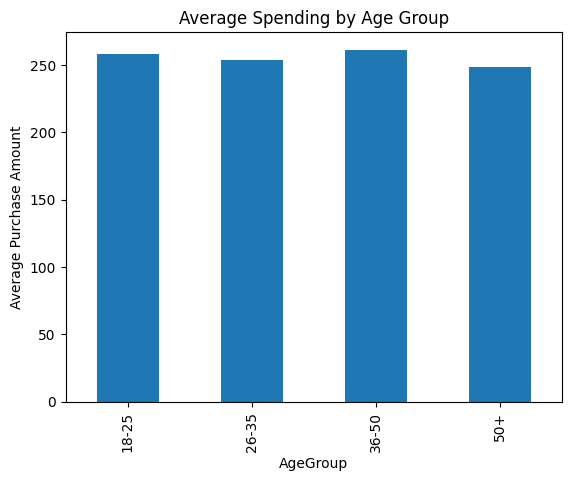

In [13]:
# Age Group Analysis
df["AgeGroup"] = pd.cut(df["Age"],
                        bins=[18,25,35,50,70],
                        labels=["18-25","26-35","36-50","50+"])

age_spending = df.groupby("AgeGroup")["PurchaseAmountUSD"].mean()
print("\nAge Group Average Spending:\n", age_spending)

plt.figure()
age_spending.plot(kind="bar")
plt.title("Average Spending by Age Group")
plt.ylabel("Average Purchase Amount")
plt.show()

In [14]:
# Season Impact

season_spending = df.groupby("Season")["PurchaseAmountUSD"].mean()
print("\nSeason Wise Average Spending:\n", season_spending)


Season Wise Average Spending:
 Season
Fall      257.303131
Spring    259.727440
Summer    250.984564
Winter    253.220552
Name: PurchaseAmountUSD, dtype: float64


In [18]:
# Prepare Data for Clustering

features = df[["Age", "PurchaseAmountUSD", "PreviousPurchases", "ReviewRating"]]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

In [21]:
#  Apply KMeans Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_data)

print("\nCluster Distribution:\n", df["Cluster"].value_counts())


Cluster Distribution:
 Cluster
0    1453
2    1251
1    1196
Name: count, dtype: int64


In [22]:
 # Cluster Analysis

cluster_summary = df.groupby("Cluster")[["Age","PurchaseAmountUSD","PreviousPurchases","ReviewRating"]].mean()
print("\nCluster Summary:\n", cluster_summary)


Cluster Summary:
                Age  PurchaseAmountUSD  PreviousPurchases  ReviewRating
Cluster                                                               
0        39.825189         271.524542          11.461115      2.964212
1        29.353679         252.162550           3.885452      2.930602
2        54.118305         240.021767           4.596323      3.211031


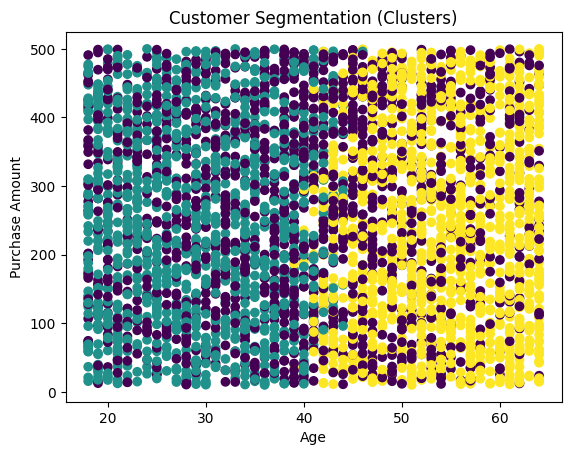

In [24]:
# Visualize Clusters

plt.figure()
plt.scatter(df["Age"], df["PurchaseAmountUSD"], c=df["Cluster"])
plt.xlabel("Age")
plt.ylabel("Purchase Amount")
plt.title("Customer Segmentation (Clusters)")
plt.show()